In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from raves import raves, run_ART, run_MoDART
from raves.src.compute_MoDART import plot_T60
from raves.src.utils.raves_io import visualize_mesh

In [2]:
environment_folder = os.path.join('..', 'example environments', 'DampenedMiddle_20_patches')

In [3]:
visualize_mesh(environment_folder)

In [4]:
# Duration of the echograms to be displayed, in seconds.
echogram_duration = 0.5
# Sample rate used for the echograms. Mostly relevant to avoid rounding errors in the propagation delays.
echogram_sample_rate = 1e4

# Source and listener positions used for the generated echograms.
source_positions = np.array([[2.1, 1.9, 1.5],
                             [5.8, 4.1, 1.5],
                             [7.2, 6.5, 1.5]])
listener_positions = np.array([[3., 3.5, 1.75],
                               [9., 3.5, 1.75],
                               [9., 9.5, 1.75],])

The environment at ..\example environments\DampenedMiddle_20_patches has already been analyzed. Existing results will be used.
	Plotting results.


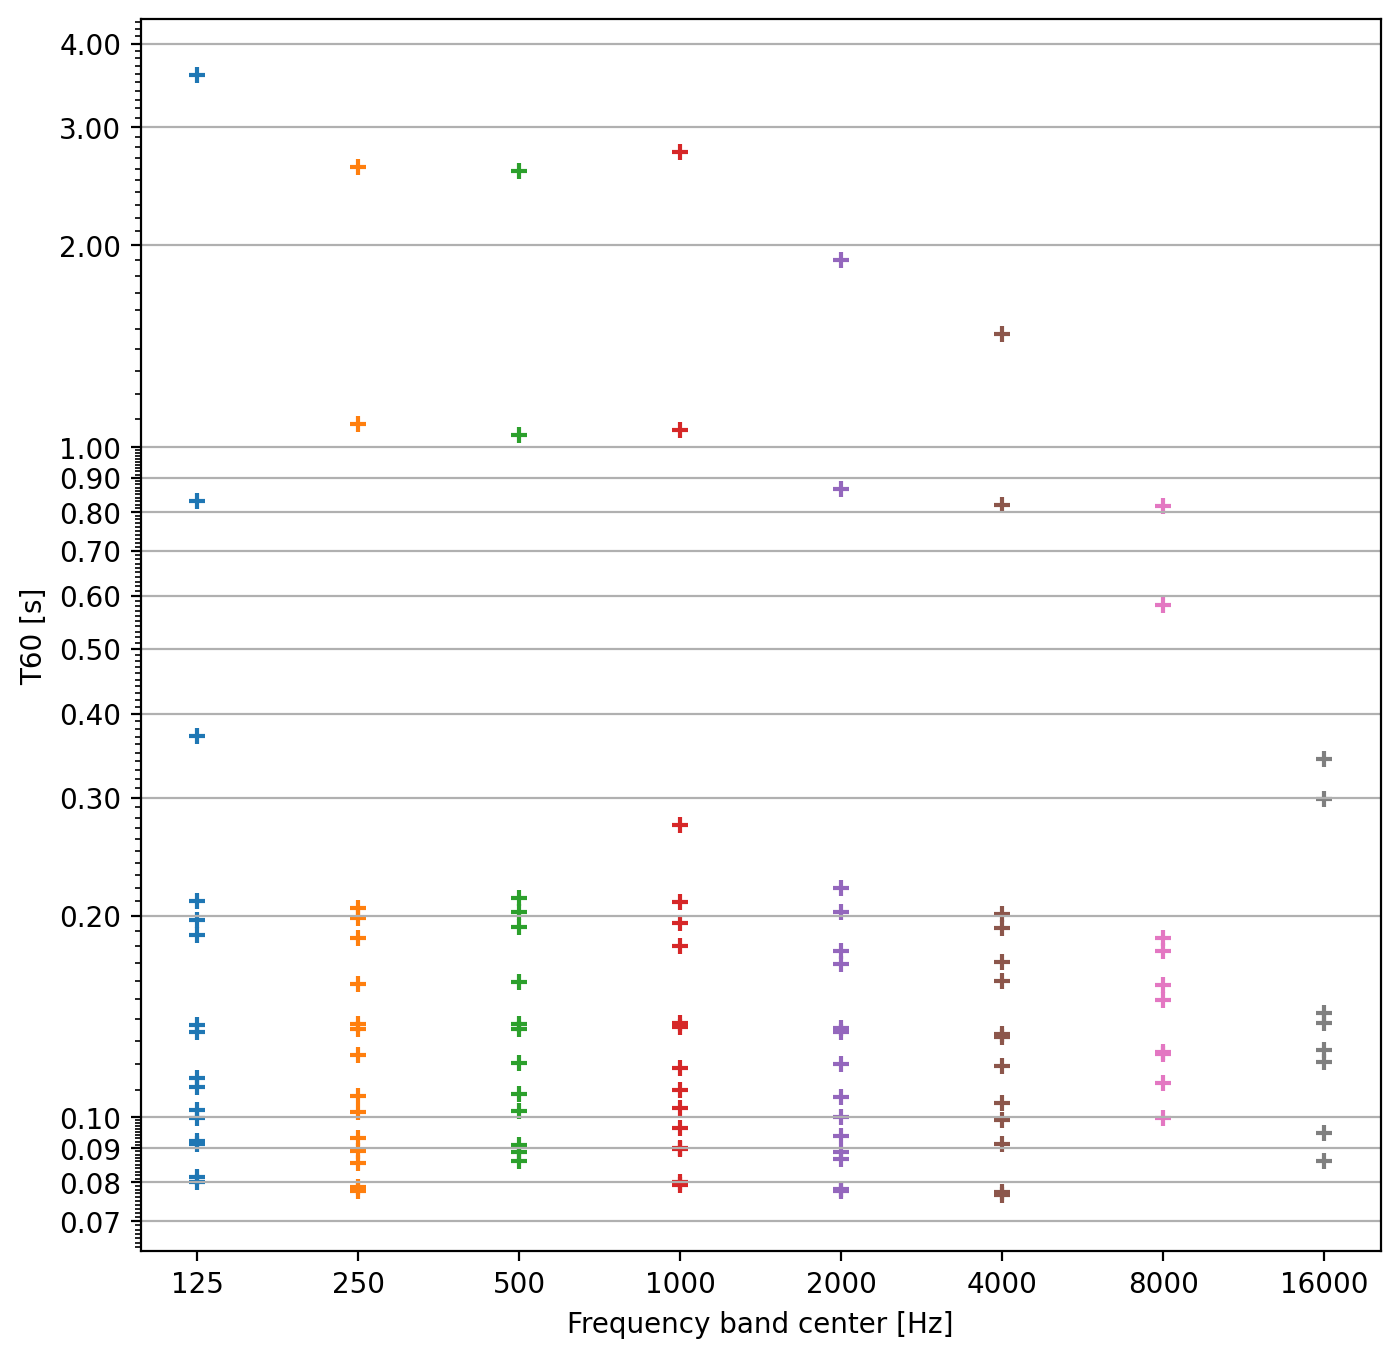

In [5]:

# If `MoD-ART.csv` exists, a full analysis has already been carried out.
# If it doesn't exist, some or all of the analysis needs to be run.
if not os.path.isfile(os.path.join(environment_folder, 'MoD-ART.csv')):
    raves(environment_folder)
else:
    print('The environment at', environment_folder, 'has already been analyzed. Existing results will be used.')

plot_T60(environment_folder, show_figure=True)

In [6]:
# Generate the echograms with TD-ART.
ART_echograms, frequencies = run_ART(environment_folder, source_positions, listener_positions,
                                     echogram_sample_rate=echogram_sample_rate,
                                     echogram_duration=echogram_duration)

Running `run_ART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
All components ready. Assembling echograms.
	Frequency band 1...
	Frequency band 2...
	Frequency band 3...
	Frequency band 4...
	Frequency band 5...
	Frequency band 6...
	Frequency band 7...
	Frequency band 8...
Adding line-of-sight components where unobstructed.


In [7]:

# Generate the echograms with MoD-ART.
MoDART_echograms, _, _ = run_MoDART(environment_folder, source_positions, listener_positions,
                                    echogram_sample_rate=echogram_sample_rate,
                                    echogram_duration=echogram_duration)

Running `run_MoDART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
All residues ready. Assembling echograms.
Adding line-of-sight components where unobstructed.


In [8]:
# Clip the echograms strictly above 0 and convert to dB.
ART_echograms = np.clip(ART_echograms, 1e-20, None)
MoDART_echograms = np.clip(MoDART_echograms, 1e-20, None)
ART_echograms_dB = 10 * np.log10(ART_echograms)
MoDART_echograms_dB = 10 * np.log10(MoDART_echograms)

# Prepare a time axis.
time_axis = np.arange(0, ART_echograms.shape[-1]) / echogram_sample_rate
num_bands = len(frequencies)
num_sources = len(source_positions)
num_listeners = len(listener_positions)

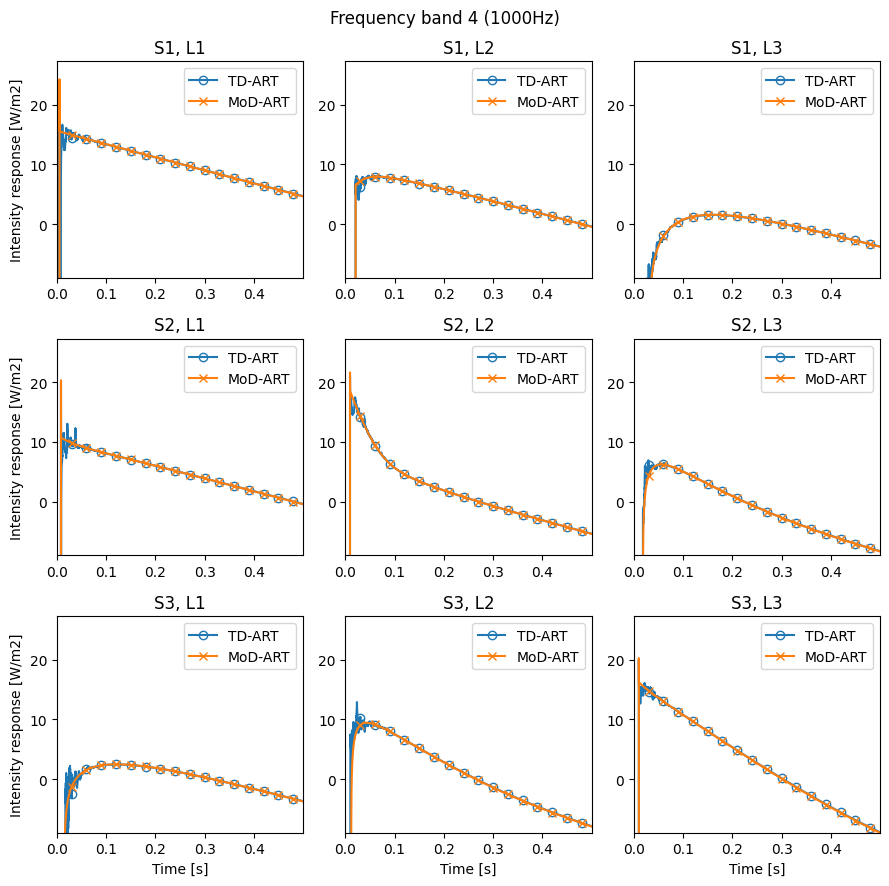

In [9]:
displayed_band_idx = 3

# Consider the extent of the dB range to be plotted.
max_extent = max(np.max(ART_echograms_dB[:, :, displayed_band_idx, :]),
                 np.max(MoDART_echograms_dB[:, :, displayed_band_idx, :]))
min_extent = min(np.min(ART_echograms_dB[:, :, displayed_band_idx, -1]),
                 np.min(MoDART_echograms_dB[:, :, displayed_band_idx, -1]))

fig, ax = plt.subplots(num_sources, num_listeners,
                       figsize=(3*num_listeners, 3*num_sources))

for s in range(num_sources):
    for l in range(num_listeners):
        ax[s, l].plot(time_axis, ART_echograms_dB[s, l, displayed_band_idx],
                      label='TD-ART', marker='o', fillstyle='none',
                      markevery=int(3e-2 * echogram_sample_rate))
        ax[s, l].plot(time_axis, MoDART_echograms_dB[s, l, displayed_band_idx],
                      label='MoD-ART', marker='x',
                      markevery=int(3e-2 * echogram_sample_rate))
        
        ax[s, l].legend()
        ax[s, l].set_xlim(0, time_axis[-1])
        ax[s, l].set_ylim(min_extent, max_extent + 3)
        
        ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
        if l == 0:
            ax[s, l].set_ylabel('Intensity response [W/m2]')
        if s == num_sources-1:
            ax[s, l].set_xlabel('Time [s]')

plt.suptitle('Frequency band {} ({:.0f}Hz)'.format(displayed_band_idx+1, frequencies[displayed_band_idx]))
plt.tight_layout()

plt.show()